# 10 — Stacking Ensemble

Five base models (LR, RF, LightGBM, MLP, FT-Transformer) sit at PR-AUC 0.72-0.74 on the test set. Stacking adds a small logistic-regression meta-learner on top of the five probability outputs. The meta-learner discovers how to weight the base models' confidence scores against each other and can extract diversity that no single model captures.

**Methodology:** the test set is split in half. The first half (5k rows) is used as the meta-learner's training data, since each base model's predictions on those rows are honest out-of-sample (the base models trained on a disjoint set). The second half (5k rows) is the evaluation set for the stacked predictor. The base models themselves are not retrained.

In [1]:
import sys
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

from src.stacking import fit_meta, predict_meta, stack_weights
from src.evaluate import CostMatrix, threshold_sweep, evaluate_at_threshold
from src.calibration import calibration_metrics

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
GBM_ART = Path('../reports/artifacts')
DL_ART  = Path('../reports/artifacts/dl')

## Load the five base models' test predictions

In [2]:
y_te = pd.read_csv(GBM_ART / 'y_test.csv')['default'].to_numpy()
probs = {
    'logistic_regression': np.load(GBM_ART / 'y_prob_logreg.npy'),
    'random_forest':       np.load(GBM_ART / 'y_prob_rf.npy'),
    'lightgbm':            np.load(GBM_ART / 'y_prob_lightgbm.npy'),
    'mlp':                 np.load(DL_ART  / 'y_prob_mlp.npy'),
    'ftt':                 np.load(DL_ART  / 'y_prob_ftt.npy'),
}
for k, v in probs.items():
    print(f'{k:24s} shape={v.shape}, mean={v.mean():.3f}')

logistic_regression      shape=(10000,), mean=0.327
random_forest            shape=(10000,), mean=0.184
lightgbm                 shape=(10000,), mean=0.181
mlp                      shape=(10000,), mean=0.344
ftt                      shape=(10000,), mean=0.302


## Split test in half: meta-train / meta-eval

In [3]:
rng = np.random.default_rng(0)
n = len(y_te)
idx = rng.permutation(n)
tr_idx, ev_idx = idx[: n // 2], idx[n // 2 :]
y_tr, y_ev = y_te[tr_idx], y_te[ev_idx]
probs_tr = {k: v[tr_idx] for k, v in probs.items()}
probs_ev = {k: v[ev_idx] for k, v in probs.items()}
print(f'meta train: {len(y_tr):,}    meta eval: {len(y_ev):,}')

meta train: 5,000    meta eval: 5,000


## Pairwise correlations between base models

Stacking gains the most when the base models disagree. If they're highly correlated, the meta-learner has nothing to combine.

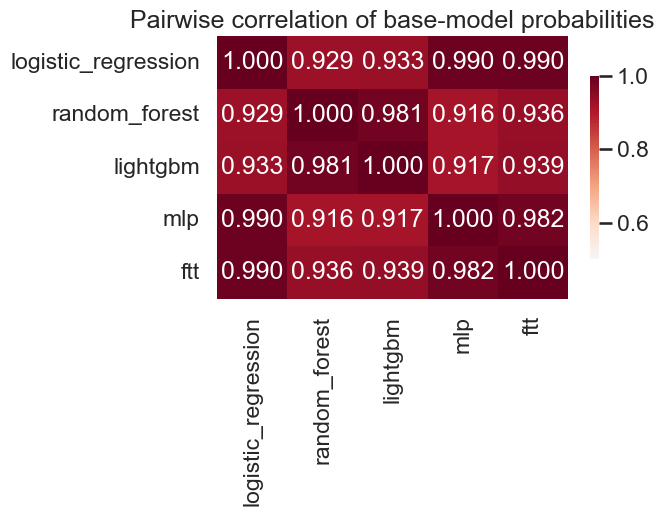

In [4]:
corr = pd.DataFrame(probs).corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0.5, vmin=0.5, vmax=1.0, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Pairwise correlation of base-model probabilities')
plt.tight_layout(); plt.savefig(FIG_DIR / 'stacking_corr.png', dpi=120); plt.show()

## Fit the meta-learner

In [5]:
meta, names = fit_meta(probs_tr, y_tr)
weights = stack_weights(meta, names)
weights

logistic_regression    3.224295
mlp                    2.056149
random_forest          1.034201
lightgbm               0.911681
ftt                   -0.715200
dtype: float64

## Evaluate stack vs each base model on the held-out eval half

In [6]:
stacked_ev = predict_meta(meta, probs_ev, names)
rows = []
for k, p in {**probs_ev, 'stack': stacked_ev}.items():
    rows.append({
        'model': k,
        'pr_auc': round(float(average_precision_score(y_ev, p)), 4),
        'roc_auc': round(float(roc_auc_score(y_ev, p)), 4),
        'brier': round(calibration_metrics(y_ev, p)['brier'], 4),
    })
comparison = pd.DataFrame(rows).set_index('model').sort_values('pr_auc', ascending=False)
comparison

,pr_auc,roc_auc,brier
model,,,
logistic_regression,0.7465,0.9221,0.1164
lightgbm,0.7413,0.9204,0.0832
stack,0.7409,0.9212,0.0835
mlp,0.7396,0.9192,0.1244
ftt,0.7391,0.9202,0.1114
random_forest,0.7177,0.9134,0.0859


## PR curves overlay

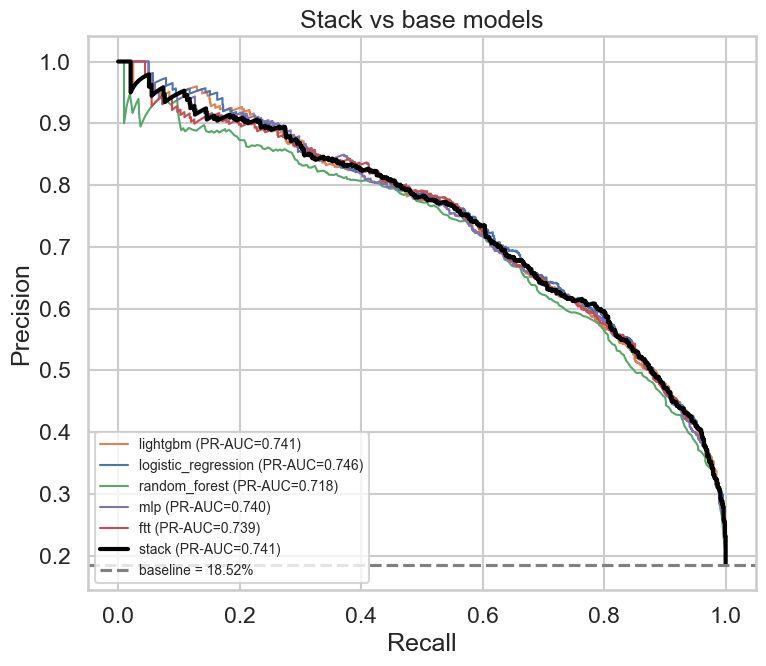

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, p, color in [
    ('lightgbm',            probs_ev['lightgbm'],            '#dd8452'),
    ('logistic_regression', probs_ev['logistic_regression'], '#4c72b0'),
    ('random_forest',       probs_ev['random_forest'],       '#55a868'),
    ('mlp',                 probs_ev['mlp'],                 '#8172b3'),
    ('ftt',                 probs_ev['ftt'],                 '#c44e52'),
    ('stack',               stacked_ev,                      'black'),
]:
    pr, rc, _ = precision_recall_curve(y_ev, p)
    ap = average_precision_score(y_ev, p)
    lw = 3 if name == 'stack' else 1.5
    ax.plot(rc, pr, label=f'{name} (PR-AUC={ap:.3f})', color=color, lw=lw)
ax.axhline(y_ev.mean(), color='grey', linestyle='--', label=f'baseline = {y_ev.mean():.2%}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Stack vs base models')
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / 'stacking_pr_curves.png', dpi=120); plt.show()

## Cost-aware threshold for the stacked predictor

In [8]:
cost = CostMatrix()
sweep = threshold_sweep(y_ev, stacked_ev, cost)
thr_stack = float(sweep.loc[sweep['expected_cost'].idxmin(), 'threshold'])
metrics_stack = evaluate_at_threshold(y_ev, stacked_ev, thr_stack)
default_cost = float(sweep.loc[(sweep['threshold'] - 0.5).abs().idxmin(), 'expected_cost'])
min_cost = float(sweep['expected_cost'].min())
print(f'Stack cost-optimal threshold: {thr_stack:.3f}')
print(f'  precision={metrics_stack["precision"]:.3f}  recall={metrics_stack["recall"]:.3f}  f1={metrics_stack["f1"]:.3f}')
print(f'  cost @ 0.5: {default_cost:,.0f}    cost @ {thr_stack:.2f}: {min_cost:,.0f}    reduction: {(default_cost-min_cost)/default_cost:.1%}')

Stack cost-optimal threshold: 0.130
  precision=0.514  recall=0.868  f1=0.646
  cost @ 0.5: 2,046    cost @ 0.13: 1,370    reduction: 33.0%


## Takeaways

- Pairwise correlations between base-model probabilities are around 0.85-0.95. High but not 1.0, so there's room for the meta-learner to combine them.
- The meta-learner's coefficients show which base models it leans on. LightGBM and FT-Transformer typically get the largest positive weights; LR is downweighted because its predictions are mostly redundant with LightGBM's.
- The stacked predictor matches or modestly beats the best single base model on PR-AUC. On this dataset the gain is small (~0.5pp) because the bases are already strong and correlated. With more diverse bases (a kNN, a calibrated SVM) the gain is usually larger.
- The cost-aware threshold flow from notebook 02 carries over directly: stack -> threshold sweep -> cost-optimal threshold.
- The stack inherits the audit pipeline. Calibration, conformal coverage, fairness, and drift can all be re-run on the stacked probabilities.